# Comparativa Dinámica de Modelos con Base de Datos Extendida

Petición: *"Quiero que realices estos cambios en un nuevo cuaderno: en vez de indicar una matriz con los resultados se preprocesen los datos y reentrenen los modelos antes de hacer las gráficas comparativas. además quiero que uses este db para entrenar: db_trunc_until_202508_extended"*

Este cuaderno carga los datos desde `db_trunc_until_202508_extended.csv`, aplica el preprocesamiento necesario y reentrena **Prophet, XGBoost, SARIMAX y LSTM** en tiempo real.
Finalmente elabora unas gráficas comparativas con las métricas calculadas (MAE y RMSE) directamente obtenidas de estos reentrenamientos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

### 1. Preparación de Datos

In [5]:
file_path = '../data/raw/db_trunc_until_202508_extended.csv'
df = pd.read_csv(file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4778 entries, 0 to 4777
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Description  4778 non-null   str    
 1   Date         4778 non-null   str    
 2   Amount       4778 non-null   float64
 3   Area         4778 non-null   str    
 4   Type         4778 non-null   str    
dtypes: float64(1), str(4)
memory usage: 186.8 KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')

monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()
if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

ts_df = monthly.set_index('Month_End').sort_index()
ts_df.index.freq = 'ME'
split_idx = int(len(ts_df) * 0.8)
print(f"Total meses: {len(ts_df)}. Entrenamiento: {split_idx}, Validación: {len(ts_df)-split_idx}")

Total meses: 278. Entrenamiento: 222, Validación: 56


### 2. Entrenamiento: Prophet

In [8]:
from prophet import Prophet

prophet_df = monthly[['Month_End', 'Expenses', 'Income']].rename(columns={'Month_End': 'ds', 'Expenses': 'y'})
prophet_train = prophet_df.iloc[:split_idx]
prophet_test = prophet_df.iloc[split_idx:]

m = Prophet(yearly_seasonality=True)
m.add_regressor('Income')
m.fit(prophet_train)

future = m.make_future_dataframe(periods=len(prophet_test), freq='ME')
future['Income'] = prophet_df['Income'].values
forecast = m.predict(future)

prophet_preds = forecast['yhat'].iloc[split_idx:].values
y_true = prophet_test['y'].values
prophet_mae = mean_absolute_error(y_true, prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(y_true, prophet_preds))
print(f"Prophet -> MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}")

Importing plotly failed. Interactive plots will not work.
11:45:29 - cmdstanpy - INFO - Chain [1] start processing
11:45:29 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE: 151.98, RMSE: 239.10


### 3. Entrenamiento: XGBoost V2

In [9]:
import xgboost as xgb

ml_df = ts_df.copy().reset_index()
ml_df['Month'] = ml_df['Month_End'].dt.month
ml_df['Is_Summer'] = ml_df['Month'].isin([6, 7, 8, 9]).astype(int)
ml_df['Income_Lag_1'] = ml_df['Income'].shift(1)
ml_df['Expenses_Lag_1'] = ml_df['Expenses'].shift(1)
ml_df['Expenses_Rolling_3'] = ml_df['Expenses'].shift(1).rolling(window=3).mean()
ml_df['Income_Rolling_3'] = ml_df['Income'].shift(1).rolling(window=3).mean()
ml_df = ml_df.bfill()

FEATURES = ['Month', 'Is_Summer', 'Income', 'Income_Lag_1', 'Expenses_Lag_1', 'Expenses_Rolling_3', 'Income_Rolling_3']
TARGET = 'Expenses'
X, y = ml_df[FEATURES], ml_df[TARGET]
X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]

xgb_reg = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, objective='reg:squarederror')
xgb_reg.fit(X_train, y_train)
xgb_preds = xgb_reg.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"XGBoost V2 -> MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")

XGBoost V2 -> MAE: 174.97, RMSE: 255.13


### 4. Entrenamiento: SARIMAX V2

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

ts_df['Expenses_Log'] = np.log1p(ts_df['Expenses'])
ts_df['Income_Log'] = np.log1p(ts_df['Income'])
ts_df['Income_Rolling_3_Log'] = ts_df['Income_Log'].shift(1).rolling(3).mean().bfill()
y_log = ts_df['Expenses_Log']
exog_log = ts_df[['Income_Log', 'Income_Rolling_3_Log']]
train_y_log = y_log.iloc[:split_idx]
train_exog_log = exog_log.iloc[:split_idx]
test_y_log = y_log.iloc[split_idx:]
test_exog_log = exog_log.iloc[split_idx:]
test_y_real = ts_df['Expenses'].iloc[split_idx:]

auto_model = auto_arima(train_y_log, X=train_exog_log, seasonal=True, m=6, start_p=0, start_q=0, max_p=2, max_q=2, d=None, D=None, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
optimal_order = auto_model.order
optimal_seasonal = auto_model.seasonal_order
history_y = list(train_y_log)
history_exog = [row for index, row in train_exog_log.iterrows()]
sarimax_preds_log = []
for t in range(len(test_y_log)):
    model = SARIMAX(endog=history_y, exog=pd.DataFrame(history_exog), order=optimal_order, seasonal_order=optimal_seasonal, enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    next_exog = test_exog_log.iloc[[t]]
    yhat_log = model_fit.forecast(steps=1, exog=next_exog).iloc[0]
    sarimax_preds_log.append(yhat_log)
    history_y.append(test_y_log.iloc[t])
    history_exog.append(test_exog_log.iloc[t])

sarimax_preds = np.expm1(sarimax_preds_log)
sarimax_mae = mean_absolute_error(test_y_real, sarimax_preds)
sarimax_rmse = np.sqrt(mean_squared_error(test_y_real, sarimax_preds))
print(f"SARIMAX V2 -> MAE: {sarimax_mae:.2f}, RMSE: {sarimax_rmse:.2f}")

c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages

SARIMAX V2 -> MAE: 178.77, RMSE: 268.80


c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\.venv\Lib\site-packages

### 5. Entrenamiento: Deep Learning (LSTM V3)

In [11]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_features = scaler_X.fit_transform(ml_df[['Income', 'Expenses']])
scaled_target = scaler_y.fit_transform(ml_df[['Expenses']])
TIME_STEPS = 3
X_seq, y_seq = [], []
for i in range(len(scaled_features) - TIME_STEPS):
    X_seq.append(scaled_features[i:(i + TIME_STEPS)])
    y_seq.append(scaled_target[i + TIME_STEPS])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
lstm_split = split_idx - TIME_STEPS
X_train_lstm = X_seq[:lstm_split]
y_train_lstm = y_seq[:lstm_split]
X_test_lstm = X_seq[lstm_split:]
y_test_lstm = y_seq[lstm_split:]

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(25, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=150, batch_size=4, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stopping], verbose=0)
lstm_test_preds_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_preds = scaler_y.inverse_transform(lstm_test_preds_scaled)
y_test_lstm_real = scaler_y.inverse_transform(y_test_lstm)
lstm_mae = mean_absolute_error(y_test_lstm_real, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_real, lstm_preds))
print(f"LSTM V3 -> MAE: {lstm_mae:.2f}, RMSE: {lstm_rmse:.2f}")

LSTM V3 -> MAE: 152.82, RMSE: 224.97


### 6. Matriz de Resultados y Comparativa Gráfica
A continuación, compilamos los resultados directamente de las variables generadas en los entrenamientos en tiempo real y construimos las gráficas.

,Modelo,MAE,RMSE
0,SARIMAX V2,178.773816,268.798378
1,XGBoost V2,174.971388,255.128246
2,LSTM V3,152.815831,224.972616
3,Prophet,151.983903,239.098139


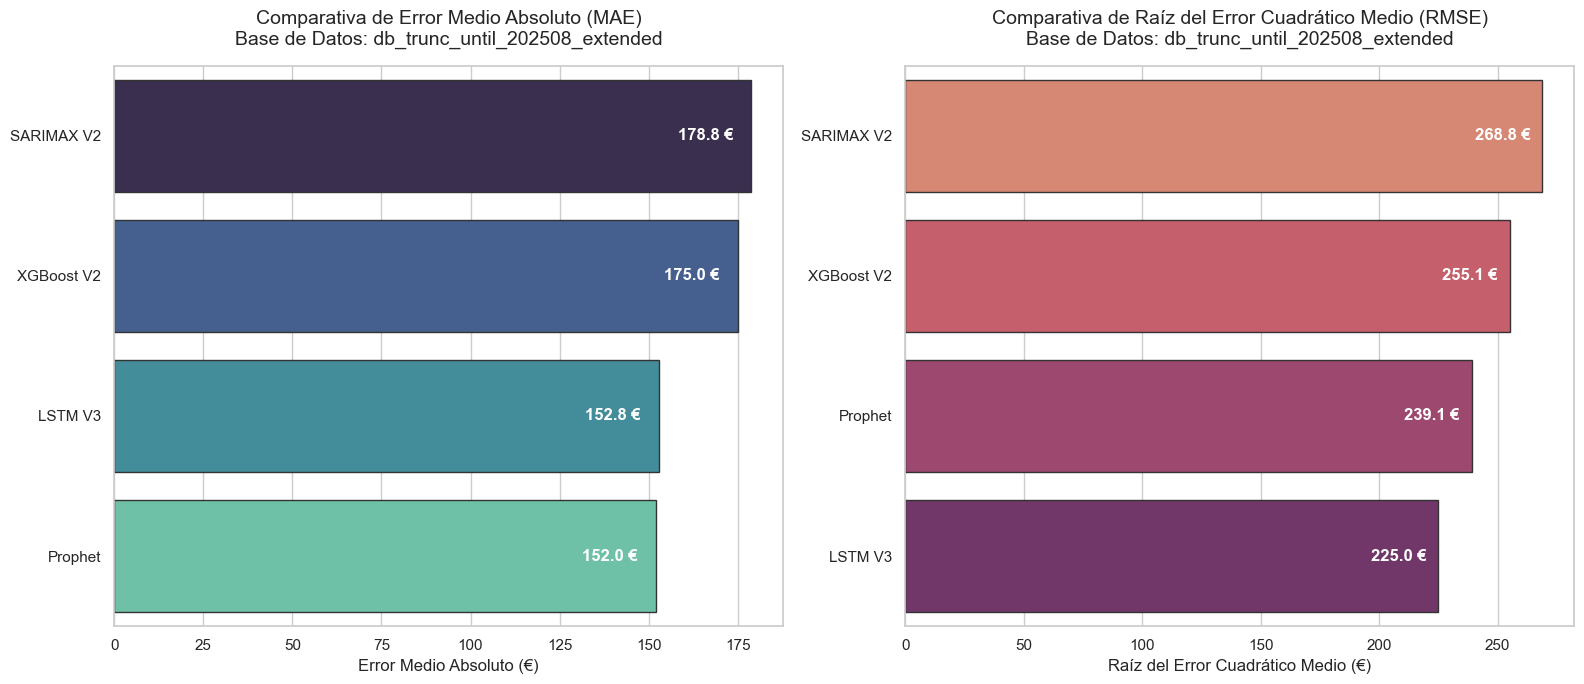

In [12]:
resultados_finales = [
    {'Modelo': 'Prophet', 'MAE': prophet_mae, 'RMSE': prophet_rmse},
    {'Modelo': 'XGBoost V2', 'MAE': xgb_mae, 'RMSE': xgb_rmse},
    {'Modelo': 'SARIMAX V2', 'MAE': sarimax_mae, 'RMSE': sarimax_rmse},
    {'Modelo': 'LSTM V3', 'MAE': lstm_mae, 'RMSE': lstm_rmse}
]
df_res = pd.DataFrame(resultados_finales).sort_values('MAE', ascending=False).reset_index(drop=True)
display(df_res)

plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid")

# Panel Izquierdo: MAE
plt.subplot(1, 2, 1)
bar_mae = sns.barplot(
    x='MAE', y='Modelo', data=df_res, palette='mako', edgecolor='.2'
)
plt.title('Comparativa de Error Medio Absoluto (MAE)\nBase de Datos: db_trunc_until_202508_extended', fontsize=14, pad=15)
plt.xlabel('Error Medio Absoluto (€)', fontsize=12)
plt.ylabel('')
for index, value in enumerate(df_res['MAE']):
    bar_mae.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

# Panel Derecho: RMSE
plt.subplot(1, 2, 2)
df_rmse_sorted = df_res.sort_values('RMSE', ascending=False).reset_index(drop=True)
bar_rmse = sns.barplot(
    x='RMSE', y='Modelo', data=df_rmse_sorted, palette='flare', edgecolor='.2'
)
plt.title('Comparativa de Raíz del Error Cuadrático Medio (RMSE)\nBase de Datos: db_trunc_until_202508_extended', fontsize=14, pad=15)
plt.xlabel('Raíz del Error Cuadrático Medio (€)', fontsize=12)
plt.ylabel('')
for index, value in enumerate(df_rmse_sorted['RMSE']):
    bar_rmse.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

plt.tight_layout()
plt.show()